# Visualización de datos

**Seminario de Actualización — Unidad 5**
Práctica principal: visualización narrativa de datos con Python y SQL

## Objetivos de la clase

1. Entender por qué un resumen numérico no reemplaza a un gráfico.
2. Producir los cuatro gráficos básicos con `matplotlib`, `seaborn` y el método `.plot()` de pandas.
3. Elegir el tipo de gráfico según la pregunta, no según la estética.
4. Reconocer y evitar las formas más comunes de gráfico engañoso.
5. Aplicar la regla de la unidad: agregar en SQL, graficar en Python.

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["figure.dpi"] = 110

print("matplotlib:", plt.matplotlib.__version__)
print("seaborn   :", sns.__version__)

matplotlib: 3.10.0
seaborn   : 0.13.2


In [18]:
# ---------------------------------------------------------------------
# Conjunto de trabajo: la vista ValoresPedido unida a Clientes.
#
# ValoresPedido tiene IDPedido, IDCliente, IDEmpleado, EnvioPor, FechaPedido,
# FechaRequerida, FechaEnvio, cantidad y val. NO tiene Region, Pais ni Ciudad:
# esas columnas están en Clientes y hay que traerlas con un JOIN.
# ---------------------------------------------------------------------
import pandas as pd
import config_conexion
import datos_demo

CONSULTA = """
    SELECT v.IDPedido, v.IDCliente, v.IDEmpleado, v.EnvioPor,
           v.FechaPedido, v.FechaRequerida, v.FechaEnvio,
           v.cantidad, v.val,
           c.NombreEmpresa, c.Ciudad, c.Region, c.Pais
    FROM ValoresPedido AS v
      JOIN Clientes AS c
        ON c.IDCliente = v.IDCliente
"""

disponible = config_conexion.probar_conexion()

if disponible:
    engine = config_conexion.crear_engine()
    df = pd.read_sql(CONSULTA, engine)
    ORIGEN = "SQL Server"
else:
    engine = None
    tablas = datos_demo.generar_todo()
    df = tablas["ValoresPedido"].merge(
        tablas["Clientes"][["IDCliente", "NombreEmpresa", "Ciudad", "Region", "Pais"]],
        on="IDCliente", how="inner")
    ORIGEN = "datos sintéticos (datos_demo.py)"

print(f"Origen de los datos: {ORIGEN}")
print(f"Filas: {len(df)}   Columnas: {df.shape[1]}")
print(f"Columnas: {list(df.columns)}")

Origen de los datos: SQL Server
Filas: 830   Columnas: 13
Columnas: ['IDPedido', 'IDCliente', 'IDEmpleado', 'EnvioPor', 'FechaPedido', 'FechaRequerida', 'FechaEnvio', 'cantidad', 'val', 'NombreEmpresa', 'Ciudad', 'Region', 'Pais']


In [19]:
# Preparación: los mismos pasos de limpieza de la clase 22, en forma compacta.
df["FechaPedido"] = pd.to_datetime(df["FechaPedido"], errors="coerce")
df["FechaEnvio"] = pd.to_datetime(df["FechaEnvio"], errors="coerce")
df["val"] = pd.to_numeric(df["val"], errors="coerce")

# La extracción trae filas repetidas: la clave del pedido tiene que ser única.
df = df.drop_duplicates(subset=["IDPedido"])
df = df.dropna(subset=["IDCliente", "val", "FechaPedido"])

# Pais viene escrito de varias formas: se normaliza antes de agrupar.
df["Pais"] = df["Pais"].str.strip().str.upper().replace({
    "EEUU": "EE.UU.",
    "ESTADOS UNIDOS": "EE.UU.",
    "REINO  UNIDO": "REINO UNIDO",
})

# Region queda como está: dos tercios de los clientes no la tienen, y eso es
# información, no un error. Se la marca para poder agrupar sin perder filas.
df["Region"] = df["Region"].fillna("Sin región")

df = df[(df["val"] > 0) & (df["FechaPedido"] <= pd.Timestamp.today())]
df["DiasEnvio"] = (df["FechaEnvio"] - df["FechaPedido"]).dt.days

print(f"Filas listas para graficar: {len(df)}")

Filas listas para graficar: 830


## 1. Por qué visualizar: el cuarteto de Anscombe

Francis Anscombe construyó en 1973 cuatro conjuntos de datos con **prácticamente los mismos
estadísticos**: igual media de x e y, igual varianza, igual correlación y la misma recta de
regresión. Al graficarlos, las cuatro formas son radicalmente distintas.

La conclusión es directa: ninguna tabla de estadísticos reemplaza a mirar el gráfico durante
la exploración.

In [20]:
# Datos clásicos de Anscombe: cuatro grupos con los mismos estadísticos básicos,
# pero patrones muy distintos en el gráfico.
anscombe = pd.DataFrame({
    "grupo": ["I"] * 11 + ["II"] * 11 + ["III"] * 11 + ["IV"] * 11,
    "x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5] * 3
         + [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
    "y": [
        8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68,
        9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74,
        7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73,
        6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89,
    ],
})

# Los estadísticos son casi idénticos en los cuatro grupos:
anscombe.groupby("grupo").agg(
    media_x=("x", "mean"), media_y=("y", "mean"),
    desvio_y=("y", "std"),
    correlacion=("x", lambda s: s.corr(anscombe.loc[s.index, "y"])),
).round(2)


,media_x,media_y,desvio_y,correlacion
grupo,,,,
I,9.0,7.5,2.03,0.82
II,9.0,7.5,2.03,0.82
III,9.0,7.5,2.03,0.82
IV,9.0,7.5,2.03,0.82


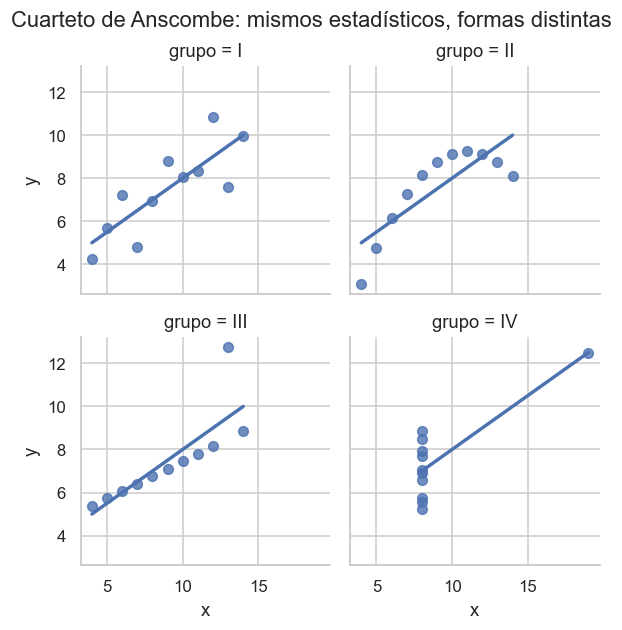

In [21]:
g = sns.lmplot(data=anscombe, x="x", y="y", col="grupo", col_wrap=2,
               height=2.8, ci=None, scatter_kws={"s": 40})
g.figure.suptitle("Cuarteto de Anscombe: mismos estadísticos, formas distintas", y=1.02)
plt.show()

## 2. Los cuatro gráficos básicos

| Tipo | Cuándo usarlo |
|---|---|
| **Barras** | Comparar una magnitud entre categorías discretas |
| **Líneas** | Mostrar la evolución de una variable a lo largo del tiempo |
| **Histograma** | Ver la distribución de una única variable numérica |
| **Diagrama de caja** | Comparar la distribución de una variable numérica entre grupos |

Comparar categorías pide barras, no un gráfico de torta. Mostrar evolución pide líneas, no
barras apiladas de muchas series.

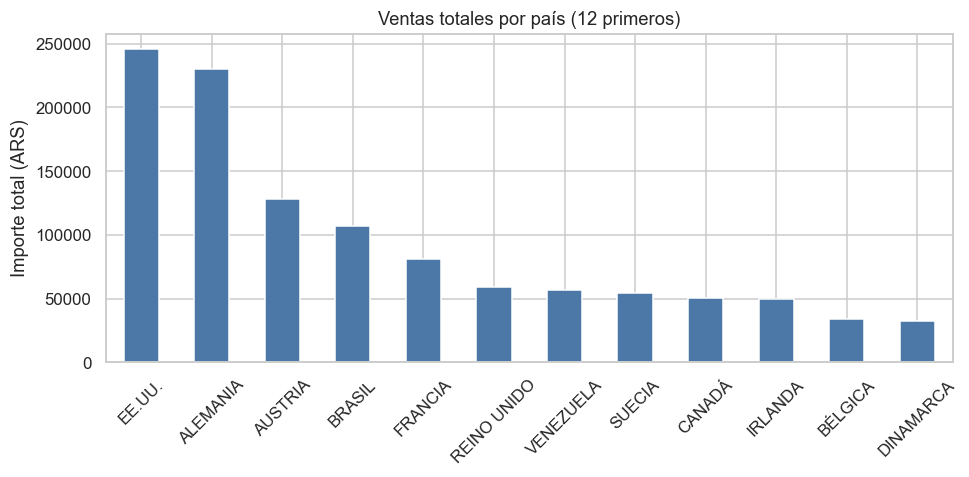

In [22]:
# BARRAS: comparación entre categorías
ventas_pais = df.groupby("Pais")["val"].sum().sort_values(ascending=False).head(12)

fig, ax = plt.subplots()
ventas_pais.plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Ventas totales por país (12 primeros)")
ax.set_xlabel("")
ax.set_ylabel("Importe total (ARS)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

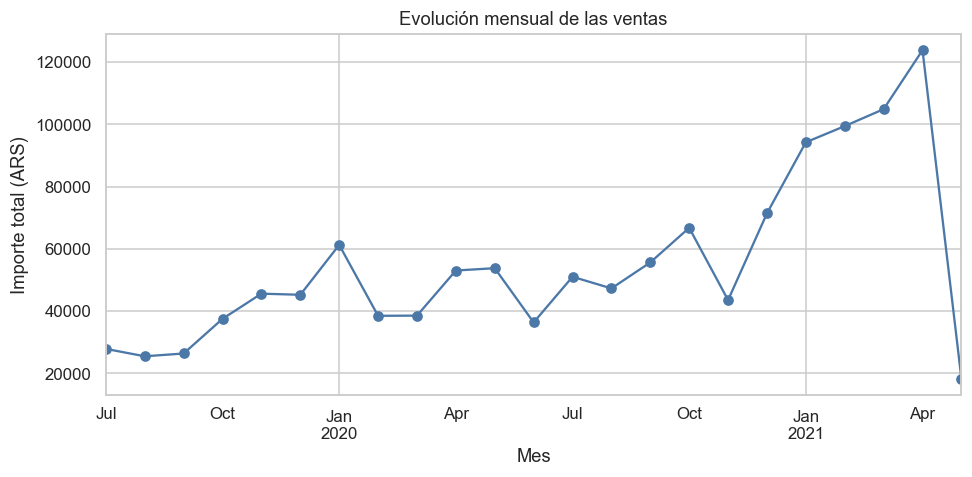

In [23]:
# LÍNEAS: evolución temporal
ventas_mes = df.groupby(df["FechaPedido"].dt.to_period("M"))["val"].sum()
ventas_mes.index = ventas_mes.index.to_timestamp()

fig, ax = plt.subplots()
ventas_mes.plot(kind="line", ax=ax, marker="o", color="#4C78A8")
ax.set_title("Evolución mensual de las ventas")
ax.set_xlabel("Mes")
ax.set_ylabel("Importe total (ARS)")
plt.tight_layout()
plt.show()

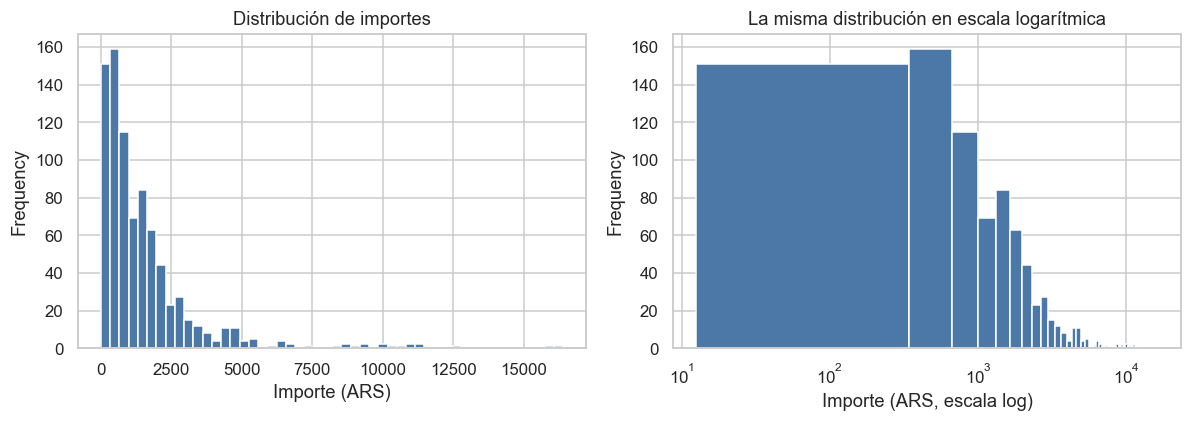

In [24]:
# HISTOGRAMA: distribución de una variable
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

df["val"].plot(kind="hist", bins=50, ax=ax1, color="#4C78A8")
ax1.set_title("Distribución de importes")
ax1.set_xlabel("Importe (ARS)")

df["val"].plot(kind="hist", bins=50, ax=ax2, color="#4C78A8", logx=False)
ax2.set_xscale("log")
ax2.set_title("La misma distribución en escala logarítmica")
ax2.set_xlabel("Importe (ARS, escala log)")

plt.tight_layout()
plt.show()

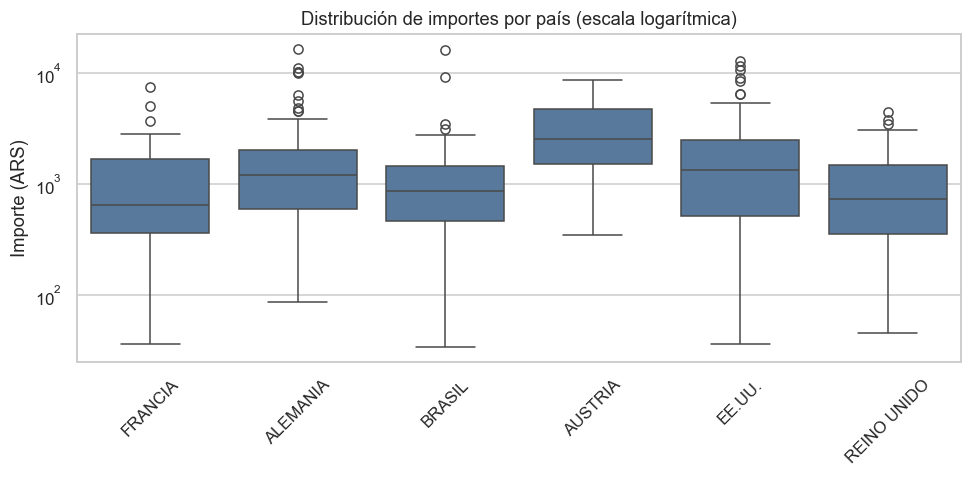

In [25]:
# DIAGRAMA DE CAJA: distribución comparada entre grupos.
# Los bigotes son exactamente la regla del IQR vista en la clase 22.
fig, ax = plt.subplots()
top = ventas_pais.head(6).index
sns.boxplot(data=df[df["Pais"].isin(top)], x="Pais", y="val",
            ax=ax, color="#4C78A8")
ax.set_yscale("log")
ax.set_title("Distribución de importes por país (escala logarítmica)")
ax.set_xlabel("")
ax.set_ylabel("Importe (ARS)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Honestidad visual: el eje truncado

Recortar el eje Y en un gráfico de barras exagera visualmente diferencias pequeñas. Es una de
las formas más comunes de gráfico engañoso, y casi siempre involuntaria: muchas herramientas
lo hacen por defecto.

La comparación siguiente muestra los **mismos datos** con y sin el eje truncado.

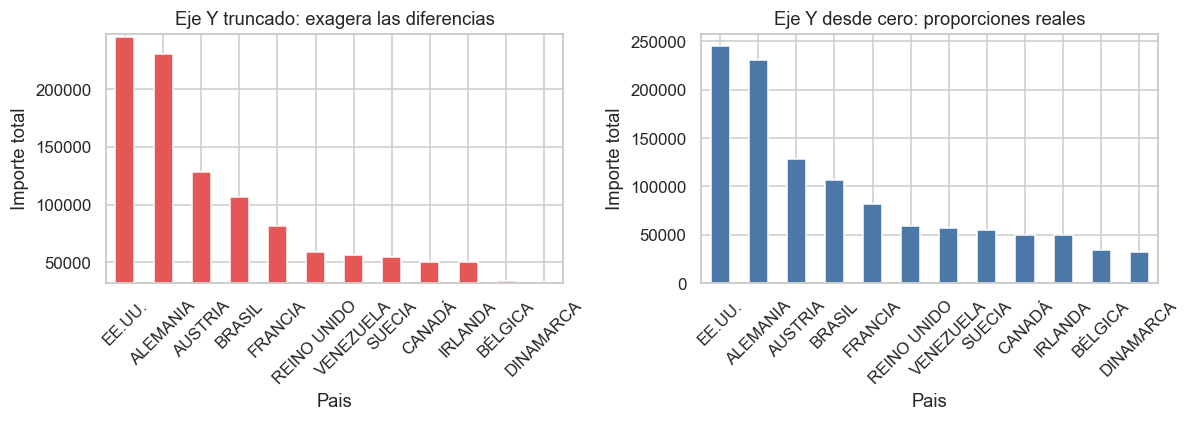

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ventas_pais.plot(kind="bar", ax=ax1, color="#E45756")
ax1.set_ylim(ventas_pais.min() * 0.98, ventas_pais.max() * 1.01)
ax1.set_title("Eje Y truncado: exagera las diferencias")
ax1.set_ylabel("Importe total")
ax1.tick_params(axis="x", rotation=45)

ventas_pais.plot(kind="bar", ax=ax2, color="#4C78A8")
ax2.set_ylim(0, ventas_pais.max() * 1.05)
ax2.set_title("Eje Y desde cero: proporciones reales")
ax2.set_ylabel("Importe total")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. De SQL a gráfico: el flujo típico

La agregación pesada se resuelve **en el motor**, con `GROUP BY`. A Python llega solo el
resultado ya reducido, listo para graficar. Traer millones de filas para sumarlas en pandas
desperdicia el optimizador de consultas y la memoria del cliente.

In [27]:
CONSULTA_AGREGADA = """
    SELECT c.Pais, SUM(v.val) AS TotalVentas, COUNT(*) AS Operaciones
    FROM ValoresPedido AS v
      JOIN Clientes AS c
        ON c.IDCliente = v.IDCliente
    WHERE v.FechaPedido >= '20190701'
    GROUP BY c.Pais
    ORDER BY TotalVentas DESC;
"""

# Nótese que se agrupa por Pais y no por Region: en Pampero, dos tercios de los
# clientes tienen Region nula, así que agrupar por región descartaría la mayor
# parte del negocio sin avisar.

if disponible:
    df_pais = pd.read_sql(CONSULTA_AGREGADA, engine)
else:
    print("Sin servidor: la agregación se simula en pandas, pero en el laboratorio")
    print("debe resolverse con esta consulta:\n")
    print(CONSULTA_AGREGADA)
    df_pais = (df.groupby("Pais", as_index=False)
                 .agg(TotalVentas=("val", "sum"), Operaciones=("IDPedido", "count"))
                 .sort_values("TotalVentas", ascending=False))

df_pais

,Pais,TotalVentas,Operaciones
0,EE.UU.,245584.64,122
1,Alemania,230284.69,122
2,Austria,128003.85,40
3,Brasil,106925.79,83
4,Francia,81358.32,77
5,Reino Unido,58971.32,56
6,Venezuela,56810.64,46
7,Suecia,54495.15,37
8,Canadá,50196.30,30
9,Irlanda,49979.91,19


## 5. Visualización narrativa

Un buen gráfico cuenta una historia: indica **qué mirar primero y por qué importa**. Tres
recursos alcanzan para la mayoría de los casos:

- Un **título que afirme el hallazgo**, en lugar de nombrar las variables.
- **Color con propósito:** destacar la categoría relevante y dejar el resto en gris.
- Una **anotación** que señale el punto que se quiere que el lector vea.

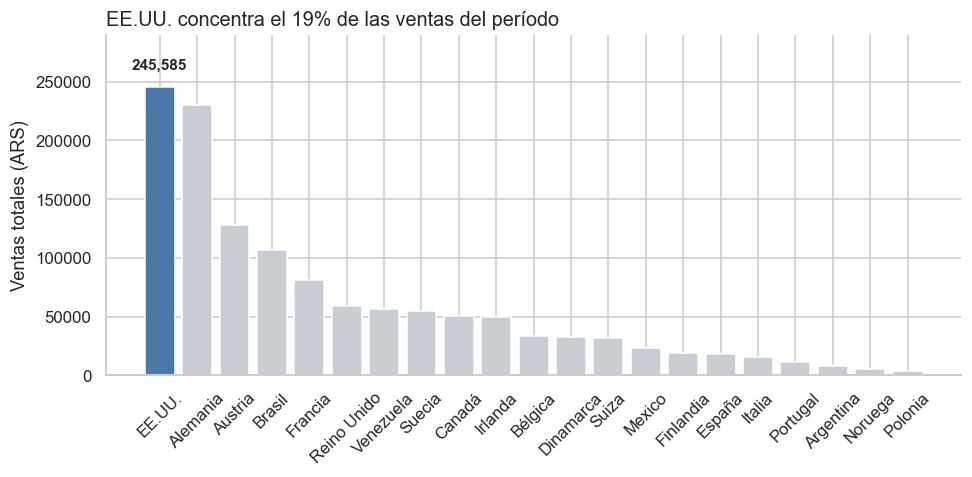

Gráfico guardado en ventas_por_region.png


In [28]:
lider = df_pais.iloc[0]
colores = ["#4C78A8" if r == lider["Pais"] else "#C8CDD4" for r in df_pais["Pais"]]
participacion = lider["TotalVentas"] / df_pais["TotalVentas"].sum() * 100

fig, ax = plt.subplots()
ax.bar(df_pais["Pais"], df_pais["TotalVentas"], color=colores)
ax.set_title(f"{lider['Pais']} concentra el {participacion:.0f}% de las ventas del período",
             fontsize=13, loc="left")
ax.set_ylabel("Ventas totales (ARS)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.annotate(f"{lider['TotalVentas']:,.0f}",
            xy=(0, lider["TotalVentas"]),
            xytext=(0, lider["TotalVentas"] * 1.06),
            ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, df_pais["TotalVentas"].max() * 1.18)
sns.despine()
plt.tight_layout()
plt.savefig("ventas_por_region.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico guardado en ventas_por_region.png")

## 6. Buenas prácticas: resumen

- Elegir el gráfico **según la pregunta**, no según lo que resulte más vistoso.
- Etiquetar siempre **ejes, unidades** y, si corresponde, leyenda.
- **No truncar el eje Y** en gráficos de barras sin advertirlo explícitamente.
- Usar el **color con propósito**, no de forma decorativa, y verificar que la paleta sea
  legible para personas con daltonismo.
- Evitar el *chartjunk* (Tufte, 1983): efectos 3D, tramas de fondo, exceso de grilla.
- Preferir **varios gráficos simples** a uno sobrecargado.